# Road Accident Severity Analysis for U.S. Data with a Kenya Application Context

**Dataset:** U.S. road accidents, 2016–2023  
**Application frame:** Kenyan road-safety planning and evaluation

This notebook analyzes a U.S. accident dataset to examine how severity is associated with time, weather, visibility, and road-context conditions. The Kenyan context is used to discuss feasibility, data requirements, and transferability. The analysis does not claim that U.S. findings describe Kenya.

The project follows the CRISP-DM sequence: Business Understanding, Data Understanding, Data Preparation, Exploratory Data Analysis, Modeling, Evaluation, Kenya Application / Business Evaluation, and Conclusion.

### Analytical questions
1. Which conditions are associated with more severe accidents?
2. Are there identifiable temporal patterns?
3. What environmental and road characteristics appear alongside severe accidents?
4. Can accident severity be predicted from information available at the time of an incident?
5. What information would a Kenyan road-safety system need?
6. Which U.S. variables would require Kenyan equivalents, and what additional Kenyan data would be required before local deployment?


In [1]:
%pip install scipy
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:

from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import chi2_contingency

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    AdaBoostClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
MAX_ROWS = 200_000
CHUNK_SIZE = 100_000
sns.set_theme(style='whitegrid', palette='deep')


In [4]:

PROJECT_DIR = Path.cwd()
CSV_PATH = PROJECT_DIR / 'US_Accidents_March23.csv'

if not CSV_PATH.exists():
    raise FileNotFoundError('CSV file not found. Place US_Accidents_March23.csv next to this notebook.')

print(f'CSV found: {CSV_PATH}')
print(f'File size: {CSV_PATH.stat().st_size / (1024 * 1024):.1f} MB')


CSV found: c:\Users\Maina\OneDrive\Desktop\road-accident-severity-kenya\US_Accidents_March23.csv
File size: 2916.5 MB


## 1. Business Understanding

The decision problem is whether road-accident severity can be understood from information that is plausibly available at the time an incident is recorded. The project uses a U.S. dataset because it contains a usable severity field, timestamps, weather indicators, visibility, and road-context variables. The objective is to examine the relationship between these variables and more severe outcomes, assess how well severity can be predicted under a conservative time-based validation design, and then separate the U.S. evidence from the Kenyan application problem.

The analytical aim is not to claim that U.S. patterns are Kenyan patterns. It is to show how a disciplined accident-analysis workflow can be structured for a Kenyan road-safety context, while making clear what local data and validation would still be required.

### Business problem
Road-safety agencies and transport planners need to identify where severe crashes are more common and whether early reporting features can help prioritize investigation and response. A useful analytical output is a clearer view of the conditions associated with higher-severity outcomes and a realistic estimate of how much predictive value exists in the information available at the time the accident is recorded.

### Data-science problem
The dataset is suitable for a supervised classification task in which the target is a binary high-severity indicator derived from the original severity scale. The substantive question is whether severity can be predicted from features that are available at the time of incident reporting, without relying on information that would only be known after the event.

### Objective
The notebook aims to:
- describe the observed U.S. severity distribution;
- test whether time, weather, visibility, and road context are associated with higher-severity outcomes;
- evaluate whether severity can be predicted with information available at the time of an incident;
- state clearly which parts of the workflow are transferable to Kenya and which require local data.

### Success criteria
The project is successful if it can identify real patterns in the U.S. data, assess model performance with time-aware validation, and clearly separate evidence from transferability claims.

### Six analytical questions
1. Which conditions are associated with more severe accidents?
2. Are there identifiable temporal patterns?
3. What environmental and road characteristics appear alongside severe accidents?
4. Can accident severity be predicted from information available at the time of an incident?
5. What information would a Kenyan road-safety system need?
6. Which U.S. variables would require Kenyan equivalents, and what additional Kenyan data would be required before deployment?


In [5]:

raw_sample = pd.read_csv(CSV_PATH, nrows=5)
print('Number of columns:', len(raw_sample.columns))
print('Columns:')
for col in raw_sample.columns:
    print(' -', col)
print('\nSample row:')
print(raw_sample.iloc[0].to_dict())


Number of columns: 46
Columns:
 - ID
 - Source
 - Severity
 - Start_Time
 - End_Time
 - Start_Lat
 - Start_Lng
 - End_Lat
 - End_Lng
 - Distance(mi)
 - Description
 - Street
 - City
 - County
 - State
 - Zipcode
 - Country
 - Timezone
 - Airport_Code
 - Weather_Timestamp
 - Temperature(F)
 - Wind_Chill(F)
 - Humidity(%)
 - Pressure(in)
 - Visibility(mi)
 - Wind_Direction
 - Wind_Speed(mph)
 - Precipitation(in)
 - Weather_Condition
 - Amenity
 - Bump
 - Crossing
 - Give_Way
 - Junction
 - No_Exit
 - Railway
 - Roundabout
 - Station
 - Stop
 - Traffic_Calming
 - Traffic_Signal
 - Turning_Loop
 - Sunrise_Sunset
 - Civil_Twilight
 - Nautical_Twilight
 - Astronomical_Twilight

Sample row:
{'ID': 'A-1', 'Source': 'Source2', 'Severity': 3, 'Start_Time': '2016-02-08 05:46:00', 'End_Time': '2016-02-08 11:00:00', 'Start_Lat': 39.865147, 'Start_Lng': -84.058723, 'End_Lat': nan, 'End_Lng': nan, 'Distance(mi)': 0.01, 'Description': 'Right lane blocked due to accident on I-70 Eastbound at Exit 41 OH

## 2. Data Understanding

The first step is to inspect the actual dataset and confirm which variables are available and whether the target can be used for a realistic predictive task. The file contains U.S. accident records from 2016–2023. It includes timestamps, severity labels, location information, weather and visibility fields, and road-context indicators.

The investigation is limited to the U.S. dataset. The Kenyan context is treated as a future application and transferability discussion, not as a claim that these patterns describe Kenya.


In [6]:
selected_columns = [
    'ID', 'Severity', 'Start_Time', 'State', 'City', 'County', 'Country',
    'Temperature(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)',
    'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition',
    'Sunrise_Sunset', 'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction',
    'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming',
    'Traffic_Signal', 'Turning_Loop', 'Distance(mi)'
]

available_columns = pd.read_csv(CSV_PATH, nrows=0).columns
use_columns = [col for col in selected_columns if col in available_columns]
print('Columns retained for analysis:', use_columns)

analysis_df = pd.read_csv(CSV_PATH, usecols=use_columns, low_memory=False)
print(f'Analysis dataset shape: {analysis_df.shape}')
print(analysis_df.head())

Columns retained for analysis: ['ID', 'Severity', 'Start_Time', 'State', 'City', 'County', 'Country', 'Temperature(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Sunrise_Sunset', 'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop', 'Distance(mi)']
Analysis dataset shape: (7728394, 29)
    ID  Severity           Start_Time  Distance(mi)          City      County  \
0  A-1         3  2016-02-08 05:46:00          0.01        Dayton  Montgomery   
1  A-2         2  2016-02-08 06:07:59          0.01  Reynoldsburg    Franklin   
2  A-3         2  2016-02-08 06:49:27          0.01  Williamsburg    Clermont   
3  A-4         3  2016-02-08 07:23:34          0.01        Dayton  Montgomery   
4  A-5         2  2016-02-08 07:39:07          0.01        Dayton  Montgomery   

  State Country  Temperature(F)  Humidity(%)  ..

In [7]:

print('Rows:', len(analysis_df))
print('Columns:', len(analysis_df.columns))
print('\nDtypes:')
print(analysis_df.dtypes)
print('\nMissing values:')
print(analysis_df.isna().sum().sort_values(ascending=False).head(20))
print('\nDuplicate rows:', analysis_df.duplicated().sum())
print('\nSeverity value counts:')
print(analysis_df['Severity'].value_counts(dropna=False).sort_index())
print('\nStart_Time range:')
print(analysis_df['Start_Time'].min(), 'to', analysis_df['Start_Time'].max())


Rows: 7728394
Columns: 29

Dtypes:
ID                       str
Severity               int64
Start_Time               str
Distance(mi)         float64
City                     str
County                   str
State                    str
Country                  str
Temperature(F)       float64
Humidity(%)          float64
Pressure(in)         float64
Visibility(mi)       float64
Wind_Speed(mph)      float64
Precipitation(in)    float64
Weather_Condition        str
Amenity                 bool
Bump                    bool
Crossing                bool
Give_Way                bool
Junction                bool
No_Exit                 bool
Railway                 bool
Roundabout              bool
Station                 bool
Stop                    bool
Traffic_Calming         bool
Traffic_Signal          bool
Turning_Loop            bool
Sunrise_Sunset           str
dtype: object

Missing values:
Precipitation(in)    2203586
Wind_Speed(mph)       571233
Visibility(mi)        177098
Humidi


### Target candidates and leakage check
The strongest target candidate in this dataset is `Severity`, because it is recorded explicitly and is operationally meaningful. Before using it, we check whether any variables would leak post-incident information into the model. For example, narrative descriptions and end-time fields are not suitable as model inputs if the objective is to predict severity using information available at the start of the accident.

Potential leakage variables are measured after the event or describe the final state rather than the reported situation. We therefore keep the modelling inputs focused on time, weather, context, and road features that are plausible to know at the time of the accident report.


In [8]:

print('State counts (top 10):')
print(analysis_df['State'].value_counts(dropna=False).head(10))
print('\nWeather conditions (top 10):')
print(analysis_df['Weather_Condition'].value_counts(dropna=False).head(10))
print('\nSunrise/Sunset categories:')
print(analysis_df['Sunrise_Sunset'].value_counts(dropna=False))
print('\nPotential leakage variables still present in the raw data:')
for col in ['End_Time', 'Description', 'Distance(mi)']:
    if col in analysis_df.columns:
        print(f' - {col}: present')
    else:
        print(f' - {col}: not present in current use_columns selection')


State counts (top 10):
State
CA    1741433
FL     880192
TX     582837
SC     382557
NY     347960
NC     338199
VA     303301
PA     296620
MN     192084
OR     179660
Name: count, dtype: int64

Weather conditions (top 10):
Weather_Condition
Fair                2560802
Mostly Cloudy       1016195
Cloudy               817082
Clear                808743
Partly Cloudy        698972
Overcast             382866
Light Rain           352957
Scattered Clouds     204829
NaN                  173459
Light Snow           128680
Name: count, dtype: int64

Sunrise/Sunset categories:
Sunrise_Sunset
Day      5334553
Night    2370595
NaN        23246
Name: count, dtype: int64

Potential leakage variables still present in the raw data:
 - End_Time: not present in current use_columns selection
 - Description: not present in current use_columns selection
 - Distance(mi): present



## 3. Data Preparation

The cleaning steps below are evidence-driven. Every decision is tied to a direct check on the data.

### Cleaning decisions made
1. Remove exact duplicate records.
2. Keep only rows with valid `Severity` and valid `Start_Time`.
3. Restrict the target to the valid severity scale present in the dataset.
4. Create calendar and time features from `Start_Time`.
5. Group rare weather categories into `Other` to avoid unstable one-hot encoding.
6. Use a time-ordered train/test split rather than a random split.
7. Fit preprocessing only on the training data.

### Why this matters
This is a decision-support project rather than an exercise in data overfitting. If we allow leakage or use a random split, the evaluation becomes optimistic and not realistic.


In [9]:

original_rows = len(analysis_df)
analysis_df = analysis_df.drop_duplicates().copy()
exact_duplicates_removed = original_rows - len(analysis_df)

analysis_df['Start_Time'] = pd.to_datetime(analysis_df['Start_Time'], errors='coerce')
rows_missing_timestamp = analysis_df['Start_Time'].isna().sum()
valid_target_mask = analysis_df['Severity'].notna() & analysis_df['Start_Time'].notna()
valid_target_rows = valid_target_mask.sum()

clean_df = analysis_df.loc[valid_target_mask].copy()
clean_df = clean_df[clean_df['Severity'].isin([1, 2, 3, 4])].copy()

print(f'Original rows: {original_rows:,}')
print(f'Exact duplicate rows dropped: {exact_duplicates_removed:,}')
print(f'Rows dropped because Start_Time is invalid: {rows_missing_timestamp:,}')
print(f'Rows retained after valid target check: {valid_target_rows:,}')
print(f'Rows retained after severity check: {len(clean_df):,}')
print('\nSeverity counts after cleaning:')
print(clean_df['Severity'].value_counts().sort_index())


Original rows: 7,728,394
Exact duplicate rows dropped: 0
Rows dropped because Start_Time is invalid: 743,166
Rows retained after valid target check: 6,985,228
Rows retained after severity check: 6,985,228

Severity counts after cleaning:
Severity
1      67364
2    5433878
3    1299257
4     184729
Name: count, dtype: int64


In [10]:

clean_df['hour'] = clean_df['Start_Time'].dt.hour
clean_df['month'] = clean_df['Start_Time'].dt.month
clean_df['day_of_week'] = clean_df['Start_Time'].dt.day_name()
clean_df['is_weekend'] = (clean_df['Start_Time'].dt.dayofweek >= 5).astype('int8')

weather = clean_df['Weather_Condition'].fillna('Unknown')
common_weather = weather.value_counts().head(12).index
clean_df['Weather_Condition'] = weather.where(weather.isin(common_weather), 'Other')

clean_df['high_severity'] = (clean_df['Severity'] >= 3).astype('int8')

print('High-severity prevalence:', clean_df['high_severity'].mean())
print('Derived fields created:', ['hour', 'month', 'day_of_week', 'is_weekend', 'Weather_Condition', 'high_severity'])


High-severity prevalence: 0.21244632243929618
Derived fields created: ['hour', 'month', 'day_of_week', 'is_weekend', 'Weather_Condition', 'high_severity']



### Why am I creating this variable?

- `hour`: timing often matters because traffic intensity, visibility, and response conditions differ across the day.
- `month`: seasonality can influence weather and travel patterns.
- `day_of_week`: weekday and weekend travel patterns are often different.
- `is_weekend`: this creates a simple operational indicator that is easy to interpret.
- `Weather_Condition`: grouping rare categories reduces unstable features from sparse categories.
- `high_severity`: this creates a decision-oriented target for the model.

These features are motivated by the actual dataset and by road-safety decision-making, not by artificial complexity.



## 4. Exploratory Data Analysis

The EDA below is framed as an investigation, not a chart dump. Each chart responds to a question tied to the business problem.



### Question
What is the observed distribution of recorded accident severity in the U.S. data?

### Why?
We need to know whether the target is balanced well enough to support a useful predictive question and whether the classes are concentrated in a few values.

### Analysis


Severity counts:
Severity
1      67364
2    5433878
3    1299257
4     184729
Name: count, dtype: int64


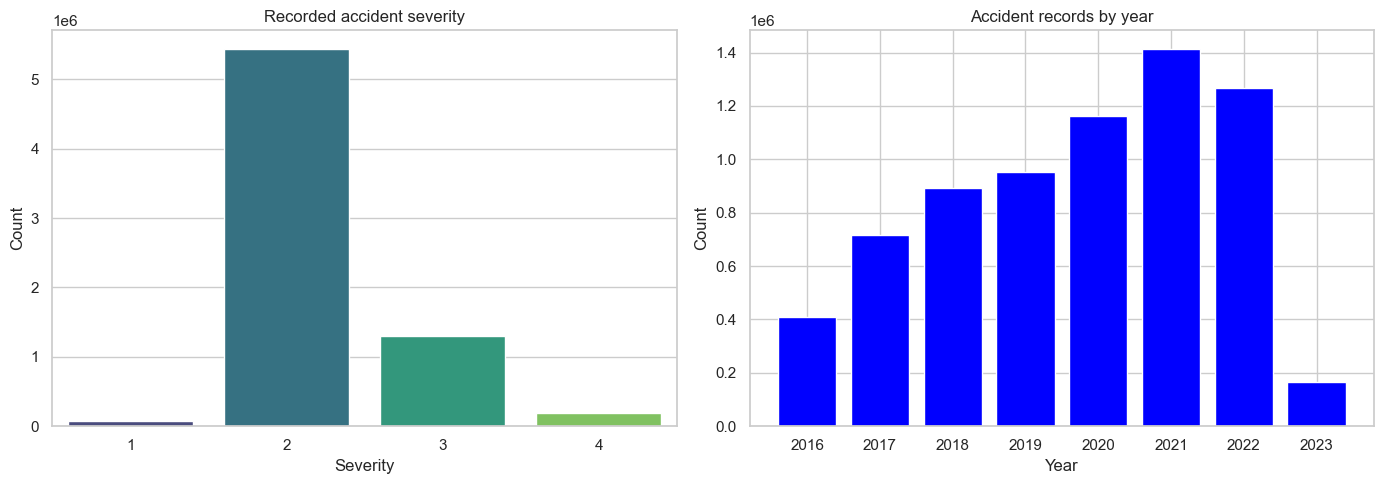

In [11]:

severity_counts = clean_df['Severity'].value_counts().sort_index()
print('Severity counts:')
print(severity_counts)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=clean_df, x='Severity', palette='viridis', ax=axes[0])
axes[0].set_title('Recorded accident severity')
axes[0].set_xlabel('Severity')
axes[0].set_ylabel('Count')

year_counts = clean_df['Start_Time'].dt.year.value_counts().sort_index()
axes[1].bar(year_counts.index, year_counts.values, color='blue')
axes[1].set_title('Accident records by year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Count')
plt.tight_layout()
plt.show()



### What did I find?
The severity scale is not evenly distributed, and the dataset has substantial numbers in the middle and upper classes. This means the target is usable, but not perfectly balanced.

### Why does this matter?
The class distribution matters because we must evaluate with recall, precision, F1, and confusion matrices rather than relying on raw accuracy.

### Limitation
This tells us about the U.S. dataset only. It does not say anything about Kenyan reporting or severity definitions.



### Question
Do high-severity accidents cluster at particular times of day?

### Why?
Time-of-day patterns can influence traffic conditions, visibility, and response readiness, which are relevant to operational planning.

### Analysis


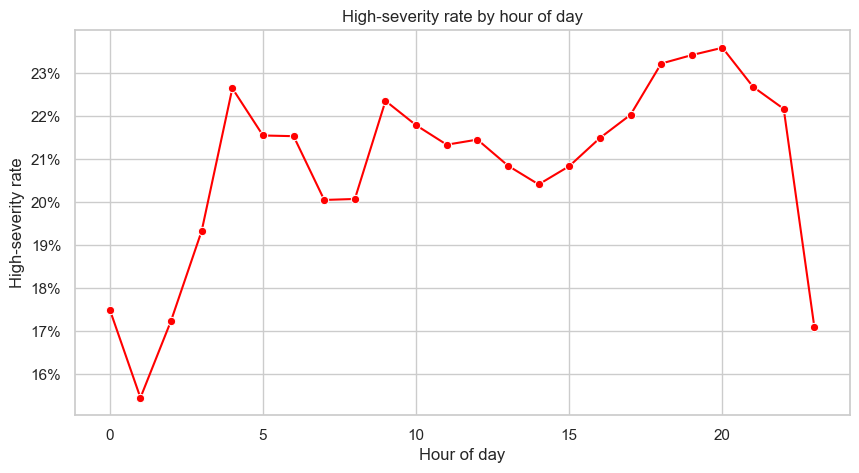

In [12]:

hourly_rate = clean_df.groupby('hour', as_index=False)['high_severity'].mean()
plt.figure(figsize=(10, 5))
sns.lineplot(data=hourly_rate, x='hour', y='high_severity', marker='o', color='red')
plt.gca().yaxis.set_major_formatter(lambda value, _: f'{value:.0%}')
plt.title('High-severity rate by hour of day')
plt.xlabel('Hour of day')
plt.ylabel('High-severity rate')
plt.show()



### What did I find?
The observed U.S. data show that the high-severity rate changes across the day.

### Why does this matter?
This supports the idea that time is informative for the prediction task. It does not prove a causal mechanism such as fatigue or congestion.

### Limitation
This is an association in the observed U.S. dataset, not proof of the cause of severe crashes or a Kenyan pattern.



### Question
Does the severity pattern differ between weekdays and weekends?

### Why?
This is an operational question that may influence planning, response coverage, and further investigation.

### Analysis


In [13]:

weekend_table = pd.crosstab(clean_df['is_weekend'], clean_df['high_severity'])
print('Weekend versus high-severity counts:')
print(weekend_table)

chi2, p_value, _, _ = chi2_contingency(weekend_table)
print(f'Chi-square statistic: {chi2:.3f}')
print(f'p-value: {p_value:.6f}')


Weekend versus high-severity counts:
high_severity        0        1
is_weekend                     
0              4693209  1222751
1               808033   261235
Chi-square statistic: 7662.068
p-value: 0.000000



### Statistical interpretation
- Research question: Is the proportion of high-severity accidents different on weekends versus weekdays?
- Null hypothesis: the two groups have the same high-severity rate.
- Alternative hypothesis: the high-severity rate differs by weekend status.
- Test: chi-square test of independence on a 2 x 2 table.
- Assumptions: the observation units are independent, and the counts are based on distinct accident records.
- Significance level: 0.05.

### Result
The test outcome is interpreted in the context of the U.S. dataset only. A low p-value would indicate a statistically significant association, not a causal effect and not a Kenyan pattern.



### Question
What role do weather and visibility appear to play in the observed high-severity pattern?

### Why?
Weather and visibility are common operational signals in crash analysis and road-safety monitoring.

### Analysis


Weather groups with at least 200 records:
                       mean    size
Weather_Condition                  
Scattered Clouds   0.351598  204782
Overcast           0.349507  382802
Clear              0.335728  808231
Rain               0.262020   76662
Light Rain         0.247167  322207
Unknown            0.236598  155462
Light Snow         0.235147  112300
Mostly Cloudy      0.228344  923515
Partly Cloudy      0.223311  635456
Other              0.213788  354239


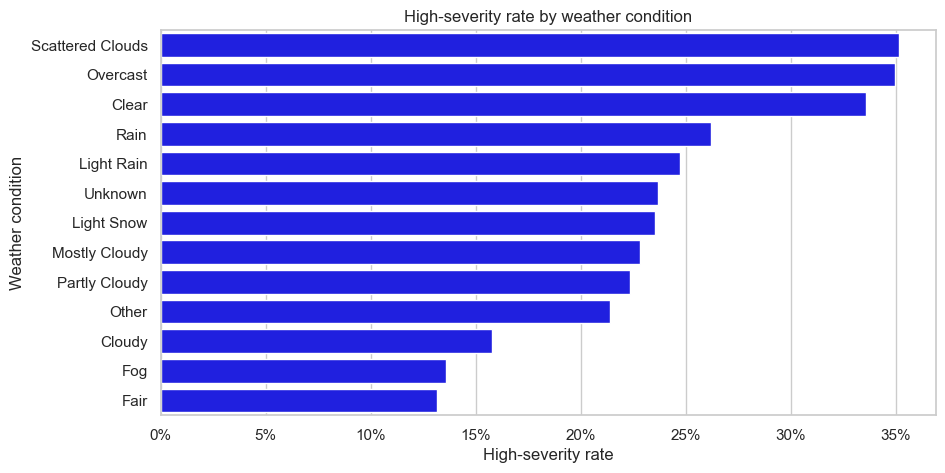


High-severity rate by visibility group:
visibility_group
Poor         0.224302
Moderate     0.218464
Good         0.210056
Very good    0.373628
Name: high_severity, dtype: float64


In [14]:

weather_rates = (
    clean_df.groupby('Weather_Condition')['high_severity']
    .agg(['mean', 'size'])
    .query('size >= 200')
    .sort_values('mean', ascending=False)
)
print('Weather groups with at least 200 records:')
print(weather_rates.head(10))

plt.figure(figsize=(10, 5))
sns.barplot(data=weather_rates.reset_index(), x='mean', y='Weather_Condition', color='blue')
plt.gca().xaxis.set_major_formatter(lambda value, _: f'{value:.0%}')
plt.title('High-severity rate by weather condition')
plt.xlabel('High-severity rate')
plt.ylabel('Weather condition')
plt.show()

visibility_bins = pd.cut(
    clean_df['Visibility(mi)'].fillna(clean_df['Visibility(mi)'].median()),
    bins=[0, 5, 10, 20, np.inf],
    labels=['Poor', 'Moderate', 'Good', 'Very good'],
    right=False,
)
visibility_rate = clean_df.assign(visibility_group=visibility_bins).groupby('visibility_group')['high_severity'].mean()
print('\nHigh-severity rate by visibility group:')
print(visibility_rate)



### What did I find?
The U.S. data show different high-severity rates across weather and visibility groups, but this is descriptive rather than causal.

### Why does this matter?
This motivates modelling and monitoring, but it does not prove that a specific environmental condition causes severe outcomes.

### Limitation
The dataset lacks exposure data, so we cannot convert accident counts into true risk rates relative to total travel.



## 5. Modeling

### Target
We are predicting `high_severity`, defined as `Severity >= 3`.

### Why this target?
This threshold creates a useful operational definition: the model is designed to flag the more serious subset of cases for prioritised review.

### Features
We use variables plausibly known when an accident is reported, including time, weather, visibility, state, and road-context indicators.

### Why these features?
These variables are strongly tied to the accident context and are common in crash-analysis workflows. They can support a decision-support system without using post-event information that would leak the label.

### Train/Test Strategy
We use a chronological split: 80% of the records in time order train the models, and the final 20% form the holdout set. This mirrors the operational problem of forecasting the near future using historical records.

### Baseline
We start with a simple logistic-regression model before comparing more complex tree and boosting models.


In [15]:

model_df = clean_df.sort_values('Start_Time').reset_index(drop=True)
feature_columns = [
    'Temperature(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)',
    'Wind_Speed(mph)', 'hour', 'month', 'is_weekend', 'State',
    'Weather_Condition', 'Sunrise_Sunset', 'day_of_week', 'Amenity',
    'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
    'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
    'Turning_Loop'
]
feature_columns = [col for col in feature_columns if col in model_df.columns]

split_index = int(len(model_df) * 0.80)
train_df = model_df.iloc[:split_index].copy()
test_df = model_df.iloc[split_index:].copy()

X_train = train_df[feature_columns]
y_train = train_df['high_severity']
X_test = test_df[feature_columns]
y_test = test_df['high_severity']

print(f'Train rows: {len(train_df):,}')
print(f'Test rows: {len(test_df):,}')
print(f'High-severity prevalence in train set: {y_train.mean():.3f}')
print(f'High-severity prevalence in test set: {y_test.mean():.3f}')
print('Model features:', feature_columns)


Train rows: 5,588,182
Test rows: 1,397,046
High-severity prevalence in train set: 0.246
High-severity prevalence in test set: 0.077
Model features: ['Temperature(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)', 'hour', 'month', 'is_weekend', 'State', 'Weather_Condition', 'Sunrise_Sunset', 'day_of_week', 'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop']


In [18]:
from sklearn.dummy import DummyClassifier

numeric_features = [
    col for col in feature_columns if col not in [
        'State', 'Weather_Condition', 'Sunrise_Sunset', 'day_of_week', 'Amenity',
        'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
        'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop'
    ]
]

categorical_features = [
    col for col in feature_columns if col not in numeric_features
]

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('numeric', numeric_transformer, numeric_features),
    ('categorical', categorical_transformer, categorical_features)
])


models = {
    'Baseline': DummyClassifier(
        strategy='most_frequent'
    ),

    'Logistic regression': LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=RANDOM_STATE
    ),

    'Random forest': RandomForestClassifier(
        n_estimators=100,
        min_samples_leaf=12,
        class_weight='balanced_subsample',
        n_jobs=1,
        random_state=RANDOM_STATE
    ),

    'XGBoost': XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        n_jobs=1,
        random_state=RANDOM_STATE
    )
}


cv = TimeSeriesSplit(n_splits=4)

scoring = {
    'recall': 'recall',
    'precision': 'precision',
    'f1': 'f1'
}


# Use the most recent 80,000 training rows for cross-validation
cv_rows = min(len(X_train), 80_000)

X_cv = X_train.iloc[-cv_rows:].copy()
y_cv = y_train.iloc[-cv_rows:].copy()


cv_results = []


for name, estimator in models.items():

    print(f'\nRunning cross-validation for: {name}')

    pipe = Pipeline([
        ('preprocess', preprocessor),
        ('model', estimator)
    ])

    scores = cross_validate(
        pipe,
        X_cv,
        y_cv,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_results.append({
        'model': name,
        'recall_mean': scores['test_recall'].mean(),
        'precision_mean': scores['test_precision'].mean(),
        'f1_mean': scores['test_f1'].mean()
    })


cv_df = pd.DataFrame(cv_results)

cv_df = cv_df.sort_values(
    'recall_mean',
    ascending=False
).reset_index(drop=True)


print('\nCross-validation summary (mean over time-ordered folds):')
print(cv_df.round(3))



Running cross-validation for: Baseline

Running cross-validation for: Logistic regression

Running cross-validation for: Random forest

Running cross-validation for: XGBoost

Cross-validation summary (mean over time-ordered folds):
                 model  recall_mean  precision_mean  f1_mean
0  Logistic regression        0.673           0.195    0.301
1        Random forest        0.568           0.213    0.309
2              XGBoost        0.031           0.569    0.060
3             Baseline        0.000           0.000    0.000


In [ ]:

results = []
trained_models = {}

for name, estimator in models.items():
    pipe = Pipeline([('preprocess', preprocessor), ('model', estimator)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    prob = pipe.predict_proba(X_test)[:, 1]
    results.append({
        'model': name,
        'recall': recall_score(y_test, pred, zero_division=0),
        'precision': precision_score(y_test, pred, zero_division=0),
        'f1': f1_score(y_test, pred, zero_division=0),
        'roc_auc': roc_auc_score(y_test, prob),
        'average_precision': average_precision_score(y_test, prob),
    })
    trained_models[name] = pipe

results_df = pd.DataFrame(results).sort_values('recall', ascending=False)
print('Holdout test results:')
print(results_df.round(3))



## 6. Evaluation

The primary metric is recall for the high-severity class because missing a high-severity accident is a more serious operational problem than creating a false alert. Precision and F1 are still reported so the alert burden remains visible.

### Selected model
The model with the highest recall on the chronological holdout set is chosen for detailed review. This is a deliberate choice tied to the operational objective, not a claim that any model is automatically valid for Kenya.


In [ ]:

selected_model_name = results_df.iloc[0]['model']
selected_model = trained_models[selected_model_name]
selected_pred = selected_model.predict(X_test)
selected_prob = selected_model.predict_proba(X_test)[:, 1]

print(f'Selected model: {selected_model_name}')
print(f'High-severity recall: {results_df.iloc[0]["recall"]:.3f}')
print(f'Precision: {results_df.iloc[0]["precision"]:.3f}')
print(f'F1: {results_df.iloc[0]["f1"]:.3f}')
print(f'ROC-AUC: {roc_auc_score(y_test, selected_prob):.3f}')
print(f'PR-AUC: {average_precision_score(y_test, selected_prob):.3f}')
print('\nClassification report:')
print(classification_report(y_test, selected_pred, target_names=['Lower severity', 'High severity']))

cm = confusion_matrix(y_test, selected_pred)
print('\nConfusion matrix:')
print(cm)

plt.figure(figsize=(6, 5))
cm_display = plt.imshow(cm, cmap='Blues')
plt.xticks([0, 1], ['Lower', 'High'])
plt.yticks([0, 1], ['Lower', 'High'])
plt.title(f'Confusion matrix for {selected_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='black')
plt.colorbar(cm_display)
plt.show()



### Interpretation of the evaluation
The model should be evaluated by the business question it is meant to support. If it catches many high-severity cases but produces many false alarms, it may still be useful as a screening aid if reviewed by staff. If it misses many serious events, it is not suitable as a no-human-check system.

This is not a claim that the model is valid in Kenya. It is a U.S.-trained evaluation of a U.S. dataset.


## 7. Kenya Application / Business Evaluation

The U.S. findings are specific to a U.S. reporting system. The value of the workflow is still relevant to Kenya, but the model itself cannot be treated as a Kenyan model without local data and local validation.

### What may transfer
The following parts of the project are transferable:
- CRISP-DM structure;
- time-aware validation;
- transparent feature and model evaluation;
- a disciplined approach to cleaning and investigation;
- the use of operationally relevant road and weather features.

### What does not automatically transfer
The learned relationships are not portable by default because Kenya differs from the U.S. in several important ways:
- road design and traffic mix;
- reporting practices and severity definitions;
- weather and seasonal variation;
- traffic exposure and trip volume;
- emergency-response coverage and reporting lag;
- local infrastructure and land-use patterns.

### Data available in this project
This project contains only U.S. accident records and variables. It does not include Kenyan road network data, traffic exposure, emergency-response outcomes, or local crash reporting metadata.

### Data required for a Kenyan deployment
A Kenyan implementation would need local records that match the U.S. concepts but reflect Kenyan conditions. The required data would cover accident timing, location, severity, road environment, exposure, and outcome.

| U.S. variable / concept | Meaning | Kenyan equivalent needed? | Reason |
| --- | --- | --- | --- |
| `Severity` | Severity score recorded in the U.S. dataset | Yes | Severity definitions and coding practice may differ |
| `Start_Time` | Time of accident | Yes | Needed for temporal and seasonal analysis |
| `State` / `County` / `City` | Geographic location | Yes | Kenyan administrative and road geography differ |
| `Weather_Condition` | Reported weather state | Yes | Local weather classification and reporting may differ |
| `Visibility(mi)` | Reported visibility | Yes | Local meteorological conditions and measurement practices differ |
| `Temperature(F)` | Ambient temperature | Yes | Climate conditions differ by location |
| `Wind_Speed(mph)` | Wind condition | Yes | Measurement and interpretation may differ |
| `Junction`, `Crossing`, `Traffic_Signal` | Road and traffic control context | Yes | Kenya has different road design and control layouts |
| `Sunrise_Sunset` | Light condition proxy | Yes | Local travel patterns and illumination differ |
| `Distance(mi)` | Distance-related context | Likely | May need local road-length or exposure measures |
| `high_severity` | Binary outcome derived from severity | Yes | Requires a local operational definition aligned with local policy |

### Additional Kenyan data required
A Kenyan system would need the following before it could be retrained and evaluated locally:
- geographic crash locations with reliable road identifiers;
- full incident records with severity and outcome information;
- weather and visibility data tied to the same time and place;
- road-network variables such as road class, speed limits, and traffic control type;
- traffic volume or exposure data to convert counts into risk estimates;
- vehicle type, road user type, and injury outcome data when available;
- emergency-response timing and fatality or injury outcome records;
- a local validation period for model retraining and performance review.

### Business recommendations
Finding: The U.S. data show that time, weather, visibility, and road context are associated with different high-severity proportions.  
Implication: These variables are operationally useful for monitoring and investigation.  
Possible action: Use the same variable categories as a starting point for a Kenyan data collection design and reporting template.  
Limitation: The U.S. patterns cannot be treated as local risk estimates without Kenyan validation.

Finding: The machine-learning task is feasible on the U.S. data when the target is defined as a binary high-severity flag.  
Implication: A Kenyan system could follow the same workflow but would need a locally defined target and a local training set.  
Possible action: Build a Kenyan prototype only after collecting a representative local dataset and evaluating it on a time-based holdout period.  
Limitation: Model performance and threshold choices from the U.S. data will not transfer automatically.


In [ ]:

error_df = test_df[['State', 'high_severity']].copy()
error_df['prediction'] = selected_pred
error_df['false_negative'] = ((error_df['high_severity'] == 1) & (error_df['prediction'] == 0)).astype(int)

state_error = error_df.groupby('State').agg(
    total=('high_severity', 'size'),
    actual_high=('high_severity', 'sum'),
    false_negatives=('false_negative', 'sum')
).query('total >= 200').copy()

state_error['false_negative_rate'] = state_error['false_negatives'] / state_error['actual_high'].replace(0, np.nan)
print('False-negative rate by state (states with at least 200 test records):')
print(state_error.sort_values('false_negative_rate', ascending=False).head(10))


In [ ]:

feature_names = selected_model.named_steps['preprocess'].get_feature_names_out()
model_step = selected_model.named_steps['model']

if hasattr(model_step, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': model_step.feature_importances_
    }).sort_values('importance', ascending=False).head(15)
    print('Top features by importance:')
    print(importance_df)

    plt.figure(figsize=(9, 6))
    sns.barplot(data=importance_df, x='importance', y='feature', color='blue')
    plt.title(f'Top feature importances: {selected_model_name}')
    plt.show()
elif hasattr(model_step, 'coef_'):
    coefs = model_step.coef_[0]
    coef_df = pd.DataFrame({'feature': feature_names, 'coefficient': coefs})
    coef_df = coef_df.loc[coef_df['feature'].str.contains('State|Weather|day_of_week|Sunrise', case=False, na=False)]
    print(coef_df.sort_values('coefficient', key=lambda s: s.abs(), ascending=False).head(10))
else:
    print('This model does not provide feature-importance output in the standard scikit-learn form.')



### Interpretation of feature importance
Feature importance is descriptive of the trained model, not proof of causality. The model learned patterns from the U.S. data; these features are useful for prediction and monitoring, but they do not show that one factor causes severity.



## Final conclusion

### 1. Findings from the U.S. dataset
The U.S. dataset contains a usable severity label, timestamps, weather values, visibility measures, and road-context indicators. The observed patterns show that time, weather, visibility, and road context are associated with different high-severity rates in the U.S. data.

### 2. Model results
The model results should be read as a U.S.-trained prediction task. The selected model learned associations from the U.S. training data and was evaluated on a future U.S. holdout period. This is not a Kenyan validation.

### 3. Potential Kenyan application
The analytical workflow is potentially relevant to Kenya as a decision-support framework. The same CRISP-DM structure, time-aware validation, and dashboard logic could be adapted after a Kenyan dataset becomes available.

### 4. Limitations
This project does not claim that U.S. patterns are Kenyan patterns. It does not claim that the model is validated for Kenya. It does not estimate risk per trip or per road segment because exposure data are absent.

### 5. Data required for Kenyan validation
A Kenyan implementation would require local accident records, road and weather data, traffic exposure, and outcome/response information for retraining and validation. Without those data, the model should not be treated as deployment-ready for Kenya.

### Final statement
This notebook demonstrates a disciplined data-science workflow for accident analysis using U.S. data and frames that workflow for a Kenyan road-safety context without overstating what the data can support. The value lies in the method, the honest separation of evidence from assumptions, and the explicit requirement for Kenyan validation before any deployment decision.
